In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from src.data_reading import parse_galaxy_data
from src.data_treatment_tools import add_radian_columns, new_CoM_procedure 
from src.tools import equatorial_to_cartesian
import matplotlib as mpl
import seaborn as sns

In [2]:
mpl.rcParams['font.size'] = 30  # Taille générale
mpl.rcParams['axes.titlesize'] = 30  # Taille des titres des graphiques
mpl.rcParams['axes.labelsize'] = 30  # Taille des labels des axes
mpl.rcParams['xtick.labelsize'] = 20  # Taille des étiquettes de l'axe x
mpl.rcParams['ytick.labelsize'] = 20  # Taille des étiquettes de l'axe y
mpl.rcParams['legend.fontsize'] = 30  # Taille de la légende
mpl.rcParams['figure.titlesize'] = 30  # Taille du titre de la figure

In [11]:
# file_path = 'data/data_CoM_CenA_M83_0.78_lg.csv'
file_path = 'data/data_CoM_CenA_M83_0.83_lg_with_muse.csv'
galaxy_df = pd.read_csv(file_path)

In [12]:
galaxy1="NGC5128_CenA"
galaxy2="NGC5236_M83"
r=0.83
# CoM_Name="CoM_CenA_M83_0.78"
CoM_Name="CoM_NGC5128_CenA_NGC5236_M83_0.83"
row_name=CoM_Name
# new_CoM_procedure(galaxy_df,galaxy1,galaxy2,r,row_name=CoM_Name,grid_incertainty=True)
# print(galaxy_df.columns)

In [5]:
G = 4.3009e-9  

# Mass calculation

In [6]:
### cuts
velocity_max = 700
velocity_min = -700

distance_max = 1


### Virial Mass

### Projected Mass

# Frequency analysis

In [7]:

def Dist3D(RA1,Dec1,Dist1,RA2,Dec2,Dist2):
    vec1=equatorial_to_cartesian(Dist1,RA1,Dec1)
    vec2=equatorial_to_cartesian(Dist2,RA2,Dec2)
    return np.linalg.norm(vec1-vec2)

def sample_asymmetric_gaussian(mean, sigma_minus, sigma_plus, size=1):
    u = np.random.rand(size)
    sigma = np.where(u < sigma_minus / (sigma_minus + sigma_plus), sigma_minus, sigma_plus)
    direction = np.where(u < sigma_minus / (sigma_minus + sigma_plus), -1, 1)
    return mean + direction * np.abs(np.random.normal(0, sigma, size))

def projected_distance(RA_series,Dec_series,Dist_series):
    RA = np.array(RA_series)
    Dec = np.array(Dec_series)
    Dist = np.array(Dist_series)
    if len(RA) != len(Dec):
        raise ValueError("Mismatched array lengths.")
    N=len(RA)
    sum_inversed_projected_distance = 0
    count=0
    for i in range(0,N):
        for j in range(i+1,N):
            Rij = Dist3D(RA[i],Dec[i],Dist[i],RA[j],Dec[j],Dist[j])# np.arccos(np.sin(Dec[i])*np.sin(Dec[j])+np.cos(Dec[i])*np.cos(Dec[j])*np.cos(RA[i]-RA[j]))*Dist
            sum_inversed_projected_distance += 1/Rij
            count +=1
    return count/sum_inversed_projected_distance

def virial_mass_monte_carlo_dis(df, velocity, galaxy_excluded, row_name="CoM_CenA_M83_0.83",
                              velocity_min=-500, velocity_max=500,distance_min=1, distance_max=3,
                              max_velocity_uncertainty=500,
                              N_samples=5000):
 
     
    # Apply the same filtering mask
    vel_col = velocity + "_" + row_name
    dis_center_col = "dis_center_" + row_name
    dis_col = "Dis"
    
    e_min_vel_col = "e_" + velocity + "_min_"+row_name
    # e_min_dis_col = "e_" + "dis_center_" + "min_"+row_name
    e_min_dis_col = "e_Dis_min"
    e_max_vel_col = "e_" + velocity + "_max_"+row_name
    # e_max_dis_col = "e_" + "dis_center_" + "max_"+row_name
    e_max_dis_col = "e_Dis_max"
    




    virial_masses = []
    sigma_velocities=[]
    projected_distances=[]
    mask_all = (
        # (galaxy_df['ref_V_h'] == 'LEDA')&
        (~df['Name'].str.startswith('CoM_')) &
        (~df['Name'].isin(galaxy_excluded)) &
        (df[vel_col] >= velocity_min) &
        (df[vel_col] <= velocity_max) &
        (df[e_min_vel_col] <= max_velocity_uncertainty) &
        (df[e_max_vel_col] <= max_velocity_uncertainty) & 
        (df[e_max_dis_col].notna()) &
        (df[e_max_vel_col].notna()) &
        (df[e_min_dis_col].notna()) &
        (df[e_min_vel_col].notna())
        )
    for K in range(N_samples):
        if K%1000==0:
            print(K)
        dis=np.random.uniform(distance_min,distance_max)
        mask = mask_all & (df[dis_center_col] <= dis) 

        df_filtered = df[mask].copy()
        RA=df_filtered["RA_radians"]
        Dec=df_filtered["Dec_radians"]
        
        # Randomly sample velocity and distance with Gaussian noise
        sampled_vel = sample_asymmetric_gaussian(
            df_filtered[vel_col].values,
            df_filtered[e_min_vel_col].values,
            df_filtered[e_max_vel_col].values,
            size=len(df_filtered)
        )
        
        sampled_dis = sample_asymmetric_gaussian(
            df_filtered[dis_col].values,
            df_filtered[e_min_dis_col].values,
            df_filtered[e_max_dis_col].values,
            size=len(df_filtered)
        )
        alpha = np.random.uniform(2,5.5)
        # Avoid division by zero or negative distances
        sampled_dis = np.clip(sampled_dis, 1e-3, None)

        # Compute sigma_v and R_g for this sample
        R_g=projected_distance(RA_series=RA,  Dec_series=Dec,  Dist_series= sampled_dis)
        sigma_v = (sampled_vel**2).mean() - sampled_vel.mean()**2
        sigma_velocities.append(sigma_v)
        projected_distances.append(R_g)
        M_vir = (alpha / G) * sigma_v * R_g
        virial_masses.append(M_vir)
   
    # Plot histogram
   
    # Convert to NumPy array and drop values outside the range
    virial_masses = np.array(virial_masses)
    
    median = np.median(virial_masses)
    sigma = np.std(virial_masses)
   
    print(f"Median Virial Mass: {median:.2e} Msun")
    print(f"Standard Deviation (σ): {sigma:.2e} Msun")
    
    sigma_velocities=np.sqrt(np.array(sigma_velocities))
    median_sigma_velocities = np.median(sigma_velocities)
    lower_sigma_velocities = np.percentile(sigma_velocities,16)
    upper_sigma_velocities = np.percentile(sigma_velocities,84)
    uncertainty_sigma_minus = median_sigma_velocities - lower_sigma_velocities
    uncertainty_sigma_plus = upper_sigma_velocities - median_sigma_velocities
   
    print(f"Median sisgma velocities: {median_sigma_velocities:.3e} km/s")
    print(f"Median projected distance: {np.median(projected_distances)}")
    print(f"Asymmetric Uncertainty: -{uncertainty_sigma_minus:.3e} / +{uncertainty_sigma_plus:.3e} km/s")
    
    
    lower = np.percentile(virial_masses, 16)
    upper = np.percentile(virial_masses, 84)
    uncertainty_minus = median - lower
    uncertainty_plus = upper - median
    
    print(f"Median Virial Mass: {median:.2e} Msun")
    print(f"Asymmetric Uncertainty: -{uncertainty_minus:.2e} / +{uncertainty_plus:.2e} Msun")
    # Define bin edges linearly spaced from 0 to 1e13
    bins = np.linspace(0, 3e13, 100)
   
    # Set a nice Seaborn style
    sns.set_style("whitegrid")

    # Créer la figure
    plt.figure(figsize=(10, 6))

    # Tracer l'histogramme sans KDE
    sns.histplot(
        virial_masses,
        bins=bins,
        color='royalblue',
        edgecolor='black',
        alpha=0.8
    )

    # Étiquettes et titre
    plt.xlabel('Virial Mass [$M_\\odot$]', fontsize=13)
    plt.ylabel('Frequency', fontsize=13)
    # plt.title('Monte Carlo Simulation of Virial Mass', fontsize=15, fontweight='bold')

    # Limites de l'axe x (optionnel)
    plt.xlim(0, 3e13)

    # Taille des ticks
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

    # Optimisation de l'espace
    plt.tight_layout()

    # Afficher
    plt.show()
   
    return virial_masses

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
Median Virial Mass: 6.41e+12 Msun
Standard Deviation (σ): 3.00e+12 Msun
Median sisgma velocities: 1.061e+02 km/s
Median projected distance: 0.7037240739604589
Asymmetric Uncertainty: -1.081e+01 / +1.449e+01 km/s
Median Virial Mass: 6.41e+12 Msun
Asymmetric Uncertainty: -2.40e+12 / +3.42e+12 Msun


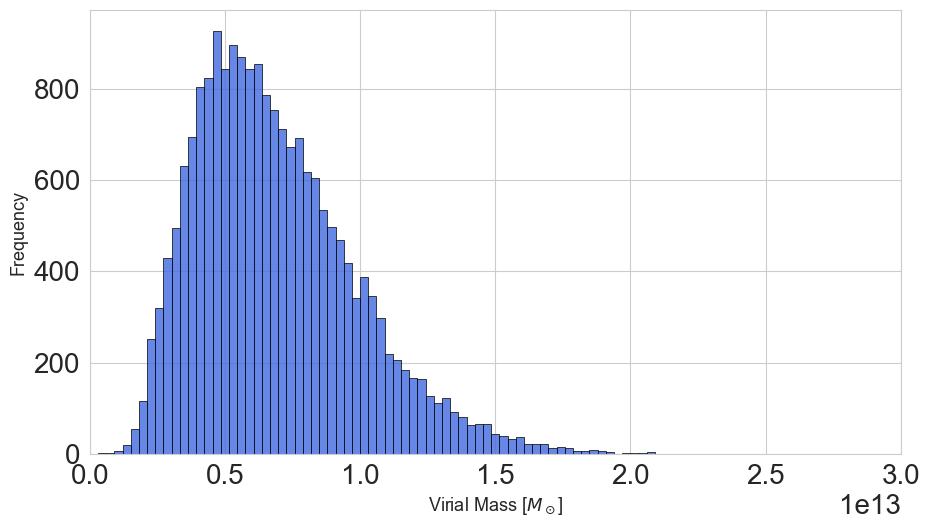

In [13]:
masses = virial_mass_monte_carlo_dis(galaxy_df,row_name=row_name, velocity="minor_infall_velocity", galaxy_excluded=[galaxy1,galaxy2],N_samples=20000)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
Median Virial Mass: 1.47e+13 Msun
Standard Deviation (σ): 7.40e+12 Msun
Median sisgma velocities: 1.593e+02 km/s
Median projected distance: 0.7007872282078166
Asymmetric Uncertainty: -1.913e+01 / +2.911e+01 km/s
Median Virial Mass: 1.47e+13 Msun
Asymmetric Uncertainty: -5.61e+12 / +7.99e+12 Msun


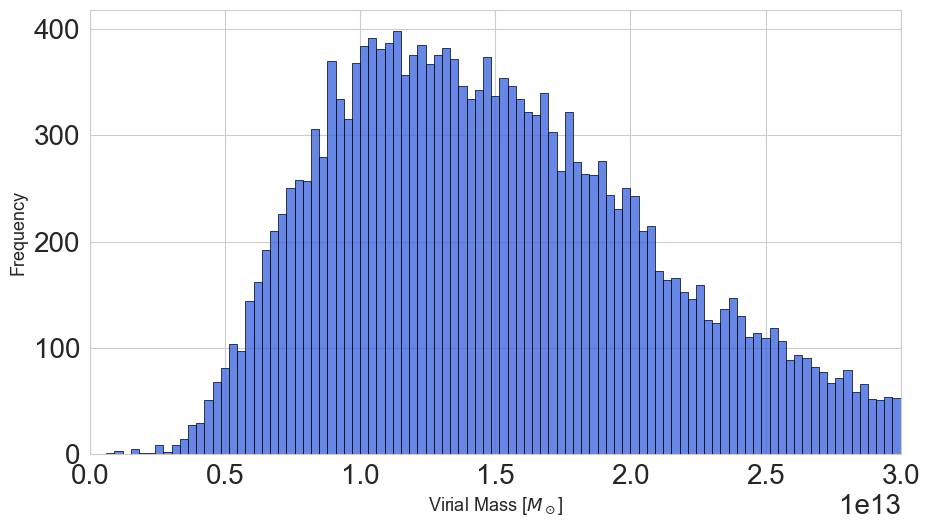

In [10]:

masses = virial_mass_monte_carlo_dis(galaxy_df,row_name=row_name, velocity="major_infall_velocity", galaxy_excluded=[galaxy1,galaxy2],N_samples=20000)